# 01 — Data Exploration: IEEE-CIS Fraud Detection

**Purpose:** Before we model anything, we look. This notebook profiles the merged IEEE-CIS dataset and answers the questions that will drive Week 2's feature engineering.

**Prerequisites:** Run `python scripts/prepare_data.py` first. It produces the parquet files this notebook reads.

**Sections:**
1. Load & basic shape
2. Class balance
3. Missing-value landscape
4. Transaction amount distribution
5. Temporal patterns
6. Feature-vs-fraud univariate signals
7. Key questions for feature engineering

In [1]:
import sys
from pathlib import Path

# Make src/ importable without pip install
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from chimera_fd.config import load_config
from chimera_fd.data.loader import load_parquet

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
cfg = load_config()
print('Config loaded. Processed dir:', cfg.data.processed_dir)

Config loaded. Processed dir: C:\Users\undeb\Documents\PROJECTS\IBM\CHIMERA-FD\data\processed


## 1. Load & basic shape

In [2]:
processed = Path(cfg.data.processed_dir) / 'ieee_cis'
train = load_parquet(processed / 'train.parquet')
val   = load_parquet(processed / 'val.parquet')
test  = load_parquet(processed / 'test.parquet')

print(f'train shape: {train.shape}')
print(f'val   shape: {val.shape}')
print(f'test  shape: {test.shape}')
print(f'\ntrain time range: {train.TransactionDT.min()} — {train.TransactionDT.max()}')
print(f'val   time range: {val.TransactionDT.min()} — {val.TransactionDT.max()}')
print(f'test  time range: {test.TransactionDT.min()} — {test.TransactionDT.max()}')
print('\n>>> Assert: train max < val min < test min (chronological order)')

train shape: (472432, 434)
val   shape: (59054, 434)
test  shape: (59054, 434)

train time range: 86400 — 12192842
val   time range: 12192900 — 13990904
test  time range: 13990941 — 15811131

>>> Assert: train max < val min < test min (chronological order)


In [3]:
# Peek at column types
dtype_counts = train.dtypes.value_counts()
print('Column dtype distribution:')
print(dtype_counts)

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f'\n{len(num_cols)} numeric columns, {len(cat_cols)} categorical columns')

Column dtype distribution:
float64    399
object      31
int64        4
Name: count, dtype: int64

403 numeric columns, 31 categorical columns


## 2. Class balance

The single most important number for choosing loss weighting and metrics.

In [4]:
balance = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows':  [len(train), len(val), len(test)],
    'fraud_count': [int(train.isFraud.sum()), int(val.isFraud.sum()), int(test.isFraud.sum())],
})
balance['fraud_rate_pct'] = 100 * balance.fraud_count / balance.rows
print(balance)

# scale_pos_weight for LightGBM: n_neg / n_pos on the training set
n_pos = int(train.isFraud.sum())
n_neg = len(train) - n_pos
print(f'\nLightGBM scale_pos_weight = n_neg / n_pos = {n_neg} / {n_pos} = {n_neg / n_pos:.2f}')

   split    rows  fraud_count  fraud_rate_pct
0  train  472432        16599        3.513522
1    val   59054         1851        3.134419
2   test   59054         2213        3.747418

LightGBM scale_pos_weight = n_neg / n_pos = 455833 / 16599 = 27.46


## 3. Missing-value landscape

IEEE-CIS has a LOT of missing values — this is normal and meaningful. We want to know which columns are almost entirely missing (drop candidates) vs partially missing (imputation candidates).

Total columns: 434
Columns >90% missing: 12
Columns >50% missing: 229
Columns  <5% missing: 112


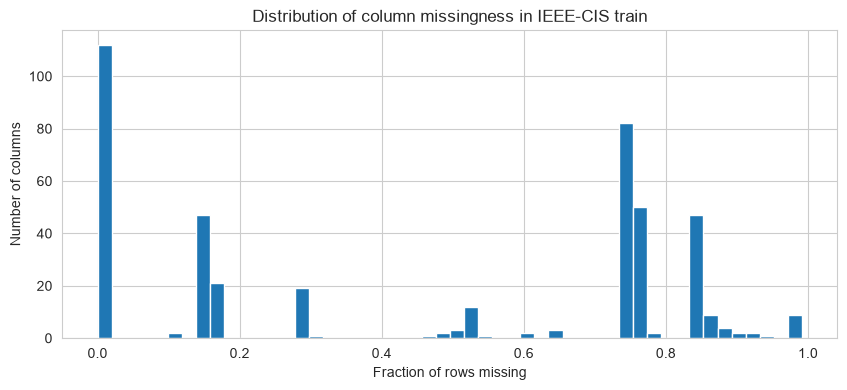

In [5]:
miss = train.isna().mean().sort_values(ascending=False)
print(f'Total columns: {len(miss)}')
print(f'Columns >90% missing: {(miss > 0.9).sum()}')
print(f'Columns >50% missing: {(miss > 0.5).sum()}')
print(f'Columns  <5% missing: {(miss < 0.05).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(miss.values, bins=50, edgecolor='white')
ax.set_xlabel('Fraction of rows missing')
ax.set_ylabel('Number of columns')
ax.set_title('Distribution of column missingness in IEEE-CIS train')
plt.show()

## 4. Transaction amount distribution

Heavy-tailed. Log scale is essential.

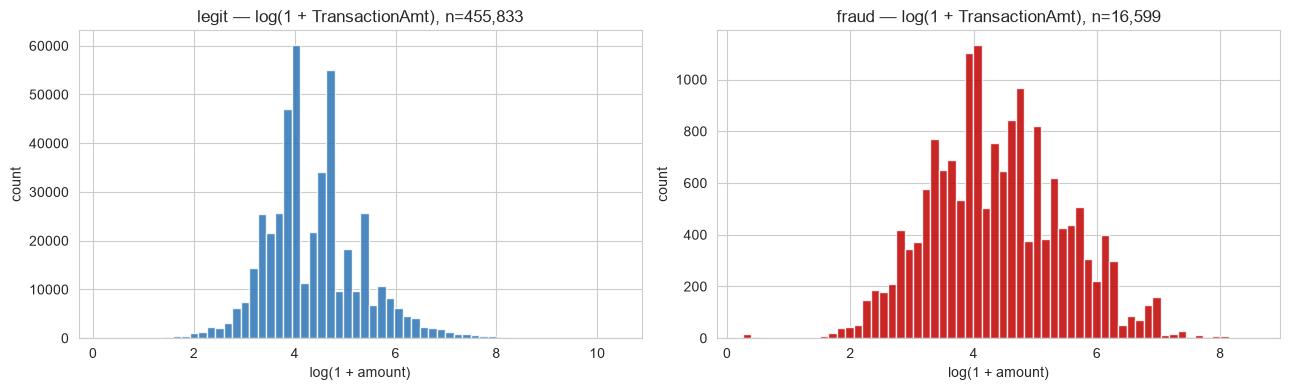


Amount stats by class:
            count        mean     50%        max
isFraud                                         
0        455833.0  133.868338  68.500  31937.391
1         16599.0  149.039733  76.129   5191.000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (df_name, df) in zip(axes, [('legit', train[train.isFraud == 0]), ('fraud', train[train.isFraud == 1])]):
    ax.hist(np.log1p(df.TransactionAmt), bins=60, alpha=0.85,
            color='#c00000' if df_name == 'fraud' else '#2e75b6', edgecolor='white')
    ax.set_title(f'{df_name} — log(1 + TransactionAmt), n={len(df):,}')
    ax.set_xlabel('log(1 + amount)')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

print('\nAmount stats by class:')
print(train.groupby('isFraud').TransactionAmt.describe()[['count', 'mean', '50%', 'max']])

## 5. Temporal patterns

IEEE-CIS uses TransactionDT as seconds from a reference date (Vesta doesn't say which one publicly). We convert to hour-of-day and day-of-week — both are strong signals in card fraud.

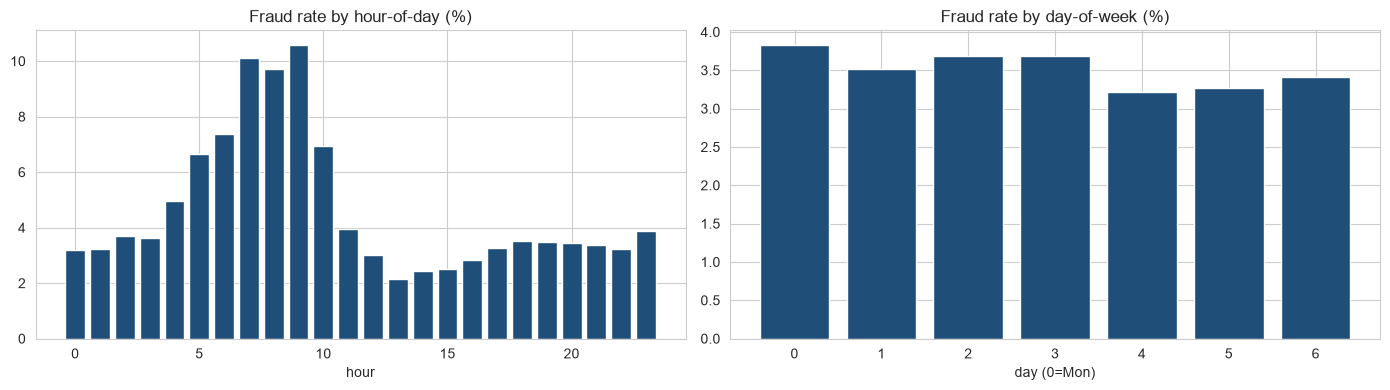

In [7]:
# TransactionDT is seconds — % 86400 gives seconds within day
hour = (train.TransactionDT % 86400) // 3600
dow  = (train.TransactionDT // 86400) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly = train.assign(hour=hour).groupby('hour').isFraud.mean() * 100
axes[0].bar(hourly.index, hourly.values, color='#1f4e79')
axes[0].set_title('Fraud rate by hour-of-day (%)')
axes[0].set_xlabel('hour')

daily = train.assign(dow=dow).groupby('dow').isFraud.mean() * 100
axes[1].bar(daily.index, daily.values, color='#1f4e79')
axes[1].set_title('Fraud rate by day-of-week (%)')
axes[1].set_xlabel('day (0=Mon)')

plt.tight_layout()
plt.show()

## 6. Categorical features vs fraud

Key categoricals in IEEE-CIS: ProductCD, card4 (card network), card6 (debit/credit), P_emaildomain, DeviceType, DeviceInfo. Look for skew — categories where fraud rate is disproportionate.

In [8]:
for col in ['ProductCD', 'card4', 'card6', 'DeviceType']:
    if col not in train.columns:
        continue
    agg = train.groupby(col).agg(n=('isFraud', 'size'), fraud_rate=('isFraud', 'mean'))
    agg['fraud_rate_pct'] = agg['fraud_rate'] * 100
    print(f'\n=== {col} ===')
    print(agg.sort_values('fraud_rate_pct', ascending=False))


=== ProductCD ===
                n  fraud_rate  fraud_rate_pct
ProductCD                                    
C           56410    0.113296       11.329551
S            8127    0.061892        6.189246
H           29691    0.046378        4.637769
R           32203    0.036301        3.630097
W          346001    0.020691        2.069069

=== card4 ===
                       n  fraud_rate  fraud_rate_pct
card4                                               
discover            5394    0.074342        7.434186
mastercard        150862    0.034906        3.490607
visa              308141    0.034724        3.472436
american express    7202    0.028603        2.860317

=== card6 ===
                      n  fraud_rate  fraud_rate_pct
card6                                              
credit           121716    0.067280        6.727957
debit            349843    0.023971        2.397075
charge card          15    0.000000        0.000000
debit or credit      30    0.000000        0.000000

In [9]:
# Top P_emaildomain categories by fraud rate (min 100 transactions to filter noise)
if 'P_emaildomain' in train.columns:
    email_agg = (train.groupby('P_emaildomain')
                      .agg(n=('isFraud', 'size'), fraud_rate=('isFraud', 'mean'))
                      .query('n >= 100')
                      .sort_values('fraud_rate', ascending=False)
                      .head(15))
    print('Top-15 P_emaildomain by fraud rate (min 100 txns):')
    print(email_agg)

Top-15 P_emaildomain by fraud rate (min 100 txns):
                      n  fraud_rate
P_emaildomain                      
mail.com            452    0.194690
aim.com             268    0.149254
outlook.es          377    0.129973
outlook.com        4080    0.091667
hotmail.es          239    0.066946
hotmail.com       37158    0.052021
gmail.com        182692    0.044003
suddenlink.net      114    0.035088
embarqmail.com      210    0.033333
frontiernet.net     153    0.032680
live.com           2475    0.031919
icloud.com         5031    0.031803
comcast.net        6496    0.030018
live.com.mx         624    0.028846
bellsouth.net      1580    0.028481
